<a href="https://www.kaggle.com/code/sonawanelalitsunil/fake-news-detection-ml-53-125?scriptVersionId=230916630" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-news-detection/fake_news_dataset.csv


## Title: Fake News Detection

#### Description: A system that uses machine learning algorithms to identify and classify fake news articles based on various linguistic, semantic, and contextual features to help combat misinformation online.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/fake-news-detection/fake_news_dataset.csv')

In [3]:
df.head()

,id,title,author,text,state,date_published,source,category,sentiment_score,word_count,...,num_shares,num_comments,political_bias,fact_check_rating,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score,label
0,1,Breaking News 1,Jane Smith,This is the content of article 1. It contains ...,Tennessee,30-11-2021,The Onion,Entertainment,-0.22,1302,...,47305,450,Center,FALSE,1,76,6,0.84,53.35,Fake
1,2,Breaking News 2,Emily Davis,This is the content of article 2. It contains ...,Wisconsin,02-09-2021,The Guardian,Technology,0.92,322,...,39804,530,Left,Mixed,1,1,5,0.85,28.28,Fake
2,3,Breaking News 3,John Doe,This is the content of article 3. It contains ...,Missouri,13-04-2021,New York Times,Sports,0.25,228,...,45860,763,Center,Mixed,0,57,1,0.72,0.38,Fake
3,4,Breaking News 4,Alex Johnson,This is the content of article 4. It contains ...,North Carolina,08-03-2020,CNN,Sports,0.94,155,...,34222,945,Center,TRUE,1,18,10,0.92,32.20,Fake
4,5,Breaking News 5,Emily Davis,This is the content of article 5. It contains ...,California,23-03-2022,Daily Mail,Technology,-0.01,962,...,35934,433,Right,Mixed,0,95,6,0.66,77.70,Real


In [4]:
df.tail()

,id,title,author,text,state,date_published,source,category,sentiment_score,word_count,...,num_shares,num_comments,political_bias,fact_check_rating,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score,label
3995,3996,Breaking News 3996,John Doe,This is the content of article 3996. It contai...,Ohio,25-04-2020,InfoWars,Technology,0.91,1227,...,38880,697,Right,Mixed,0,29,10,0.22,95.46,Fake
3996,3997,Breaking News 3997,Alex Johnson,This is the content of article 3997. It contai...,Washington,09-01-2022,CNN,Sports,-0.57,1296,...,3650,925,Left,FALSE,1,53,3,0.42,16.54,Fake
3997,3998,Breaking News 3998,Alex Johnson,This is the content of article 3998. It contai...,California,03-03-2023,Breitbart,Entertainment,-0.17,522,...,35391,577,Left,FALSE,0,22,9,0.50,28.51,Fake
3998,3999,Breaking News 3999,John Doe,This is the content of article 3999. It contai...,Illinois,13-04-2021,New York Times,Health,-0.88,169,...,40424,201,Left,FALSE,1,3,6,0.17,71.16,Real
3999,4000,Breaking News 4000,John Doe,This is the content of article 4000. It contai...,Texas,20-12-2023,The Guardian,Health,-0.95,465,...,48913,279,Right,TRUE,1,73,4,0.09,27.65,Real


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4000 non-null   int64  
 1   title              4000 non-null   object 
 2   author             4000 non-null   object 
 3   text               4000 non-null   object 
 4   state              4000 non-null   object 
 5   date_published     4000 non-null   object 
 6   source             4000 non-null   object 
 7   category           4000 non-null   object 
 8   sentiment_score    4000 non-null   float64
 9   word_count         4000 non-null   int64  
 10  char_count         4000 non-null   int64  
 11  has_images         4000 non-null   int64  
 12  has_videos         4000 non-null   int64  
 13  readability_score  4000 non-null   float64
 14  num_shares         4000 non-null   int64  
 15  num_comments       4000 non-null   int64  
 16  political_bias     4000 

In [6]:
df.describe()

,id,sentiment_score,word_count,char_count,has_images,has_videos,readability_score,num_shares,num_comments,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score
count,4000.000000,4000.000000,4000.000000,4000.0000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000
mean,2000.500000,-0.000645,795.655750,4277.0680,0.49650,0.484500,54.764595,25144.596750,489.870250,0.497000,49.960750,5.54925,0.494447,50.598110
std,1154.844867,0.574768,406.373871,2186.2073,0.50005,0.499822,14.404027,14387.537467,287.435733,0.500054,29.467911,2.87422,0.289138,28.932298
min,1.000000,-1.000000,100.000000,500.0000,0.00000,0.000000,30.020000,39.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.040000
25%,1000.750000,-0.490000,445.750000,2358.7500,0.00000,0.000000,42.480000,12781.750000,238.000000,0.000000,24.000000,3.00000,0.240000,25.915000
50%,2000.500000,-0.010000,793.000000,4287.0000,0.00000,0.000000,54.235000,25308.500000,483.000000,0.000000,50.000000,6.00000,0.490000,51.480000
75%,3000.250000,0.510000,1150.000000,6206.5000,1.00000,1.000000,67.215000,37453.500000,741.000000,1.000000,76.000000,8.00000,0.740000,75.580000
max,4000.000000,1.000000,1500.000000,7996.0000,1.00000,1.000000,79.980000,50000.000000,1000.000000,1.000000,100.000000,10.00000,1.000000,99.950000


In [7]:
df.dtypes

id                     int64
title                 object
author                object
text                  object
state                 object
date_published        object
source                object
category              object
sentiment_score      float64
word_count             int64
char_count             int64
has_images             int64
has_videos             int64
readability_score    float64
num_shares             int64
num_comments           int64
political_bias        object
fact_check_rating     object
is_satirical           int64
trust_score            int64
source_reputation      int64
clickbait_score      float64
plagiarism_score     float64
label                 object
dtype: object

In [8]:
df.shape

(4000, 24)

In [9]:
df.isnull().sum()

id                   0
title                0
author               0
text                 0
state                0
date_published       0
source               0
category             0
sentiment_score      0
word_count           0
char_count           0
has_images           0
has_videos           0
readability_score    0
num_shares           0
num_comments         0
political_bias       0
fact_check_rating    0
is_satirical         0
trust_score          0
source_reputation    0
clickbait_score      0
plagiarism_score     0
label                0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['id', 'title', 'author', 'text', 'state', 'date_published', 'source',
       'category', 'sentiment_score', 'word_count', 'char_count', 'has_images',
       'has_videos', 'readability_score', 'num_shares', 'num_comments',
       'political_bias', 'fact_check_rating', 'is_satirical', 'trust_score',
       'source_reputation', 'clickbait_score', 'plagiarism_score', 'label'],
      dtype='object')

## Data visualizations

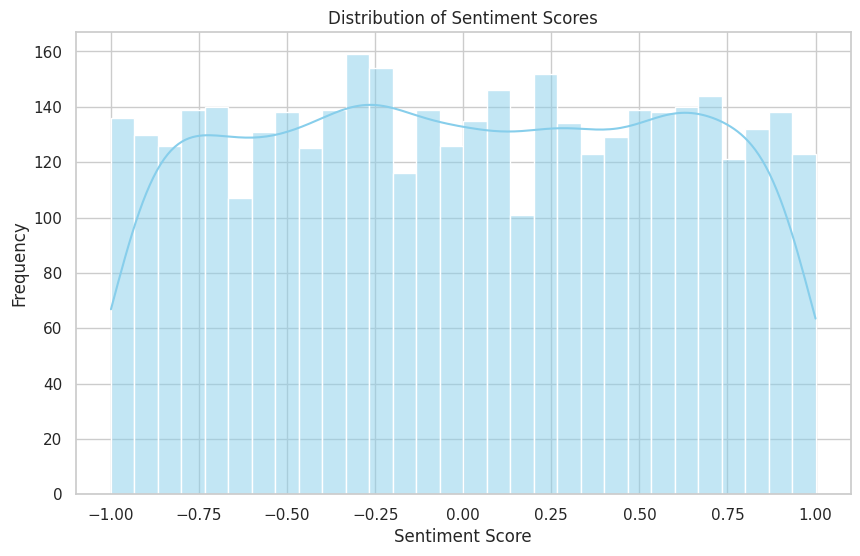

In [12]:
# Set Seaborn style
sns.set(style="whitegrid")

# 1. Distribution of Sentiment Scores
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

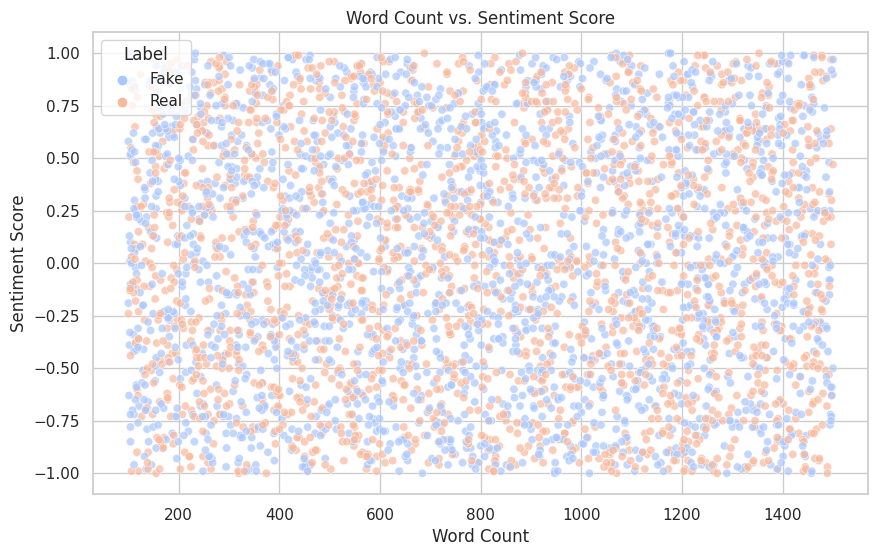

In [13]:
# 2. Word Count vs. Sentiment Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='word_count', y='sentiment_score', hue='label', palette='coolwarm', alpha=0.7)
plt.title('Word Count vs. Sentiment Score')
plt.xlabel('Word Count')
plt.ylabel('Sentiment Score')
plt.legend(title='Label')
plt.show()

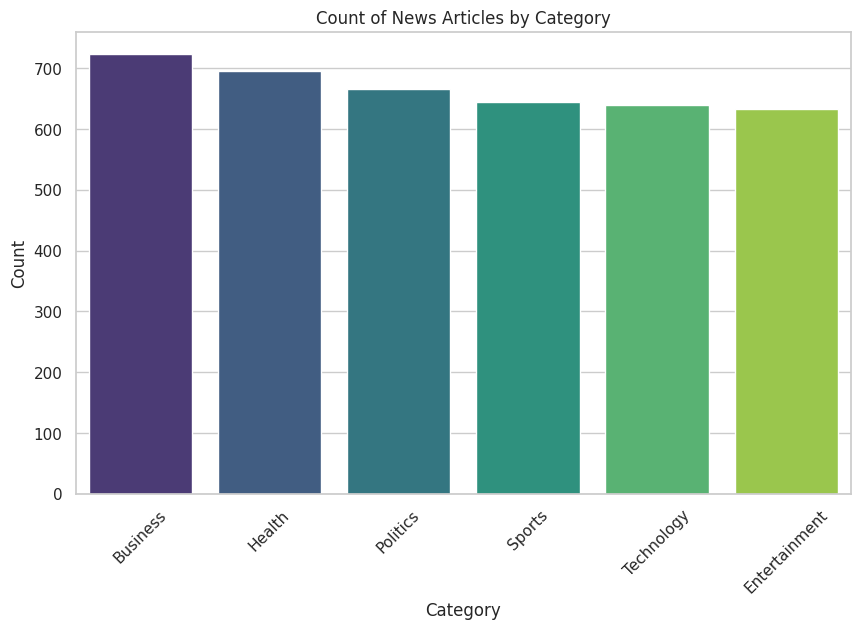

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='viridis')
plt.title('Count of News Articles by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

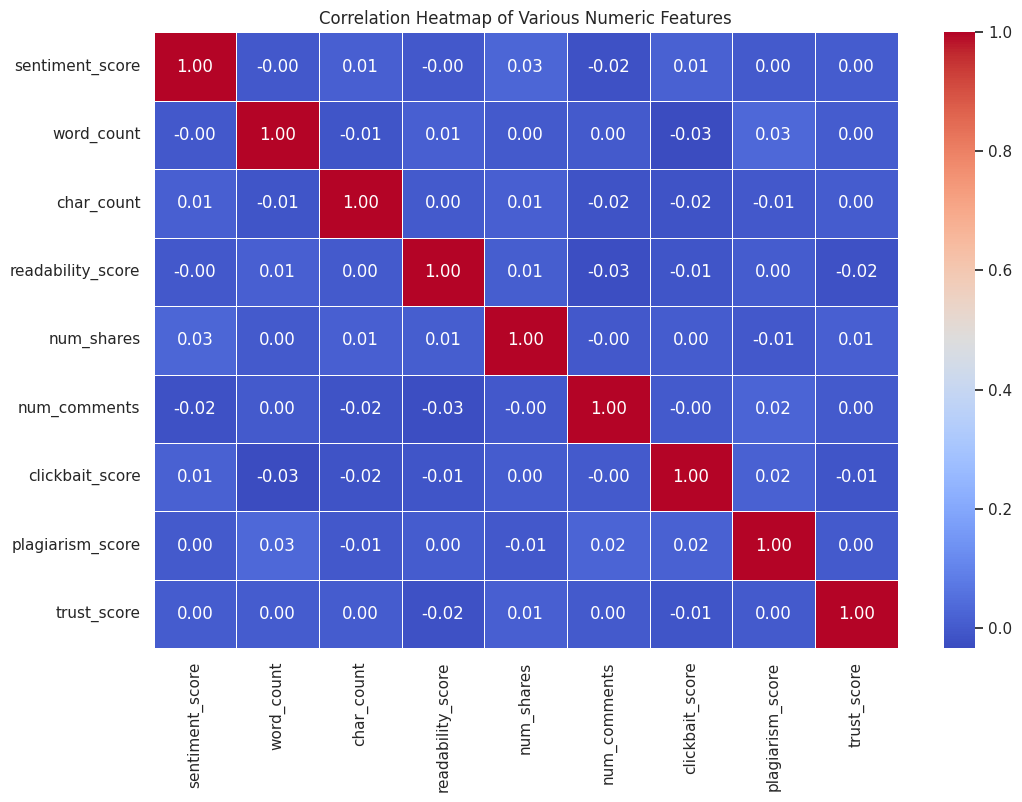

In [15]:
# 4. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[['sentiment_score', 'word_count', 'char_count', 'readability_score', 
                         'num_shares', 'num_comments', 'clickbait_score', 'plagiarism_score', 'trust_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Various Numeric Features')
plt.show()

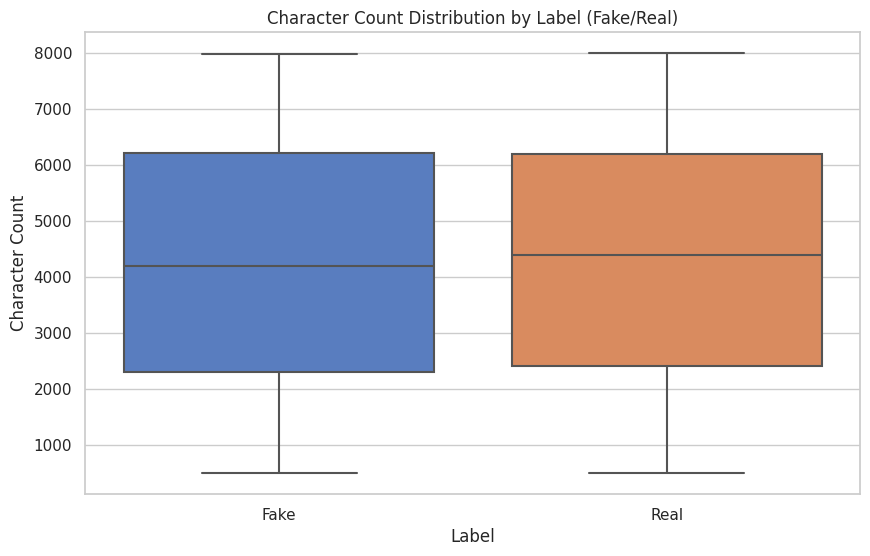

In [16]:
# 5. Distribution of Article Length (Character Count) by Label (Fake/Real)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='label', y='char_count', palette='muted')
plt.title('Character Count Distribution by Label (Fake/Real)')
plt.xlabel('Label')
plt.ylabel('Character Count')
plt.show()

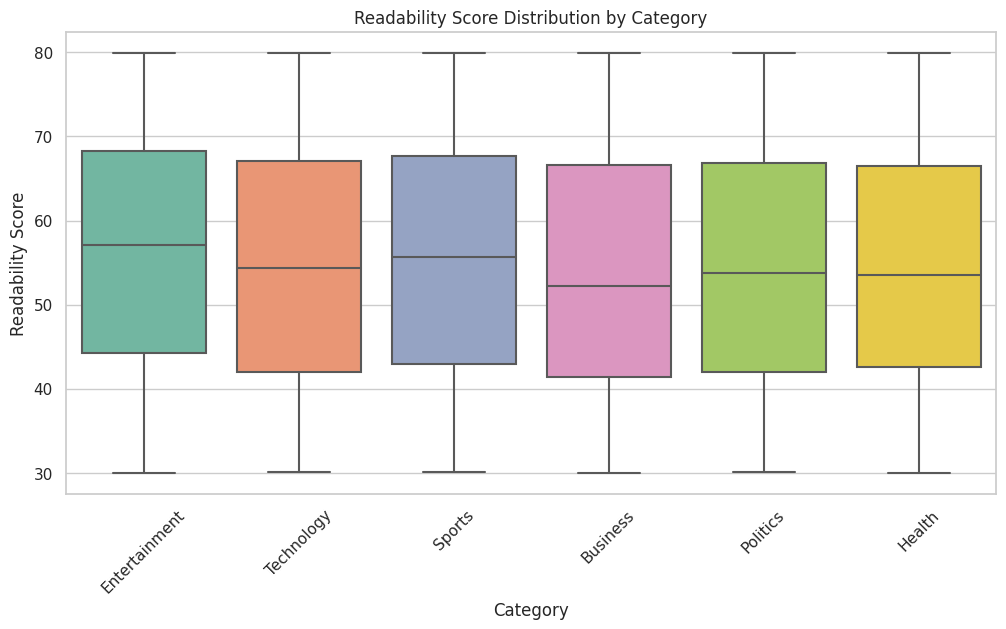

In [17]:
# 6. Article Readability Score Distribution by Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='category', y='readability_score', palette='Set2')
plt.title('Readability Score Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Readability Score')
plt.xticks(rotation=45)
plt.show()

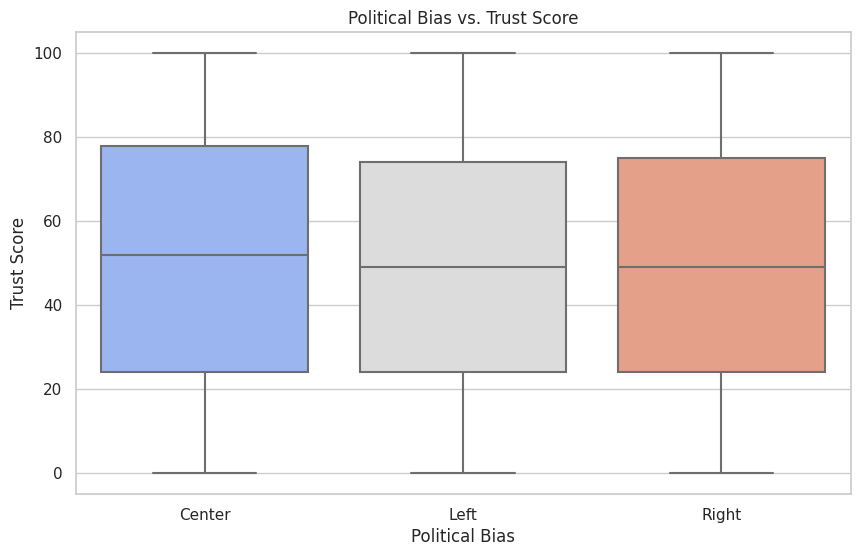

In [18]:
# 7. Political Bias vs. Trust Score
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='political_bias', y='trust_score', palette='coolwarm')
plt.title('Political Bias vs. Trust Score')
plt.xlabel('Political Bias')
plt.ylabel('Trust Score')
plt.show()

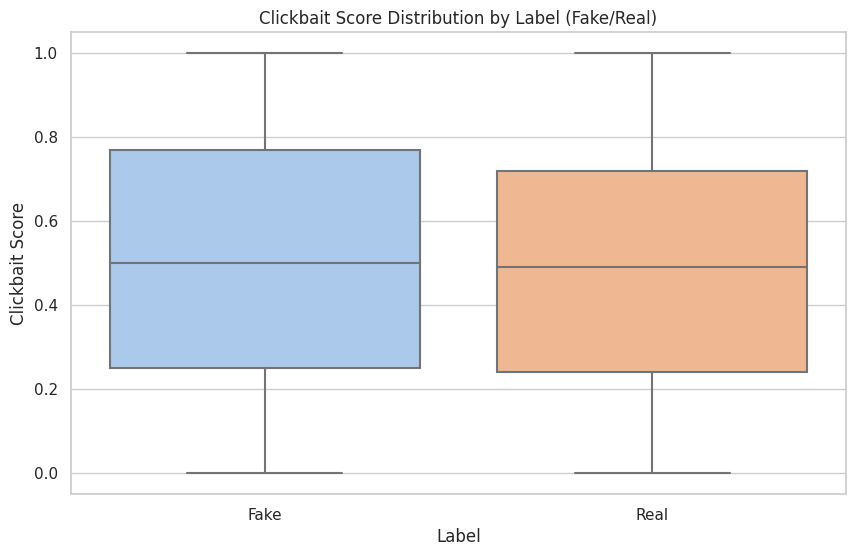

In [19]:
# 8. Distribution of Clickbait Score by Label (Fake/Real)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='label', y='clickbait_score', palette='pastel')
plt.title('Clickbait Score Distribution by Label (Fake/Real)')
plt.xlabel('Label')
plt.ylabel('Clickbait Score')
plt.show()

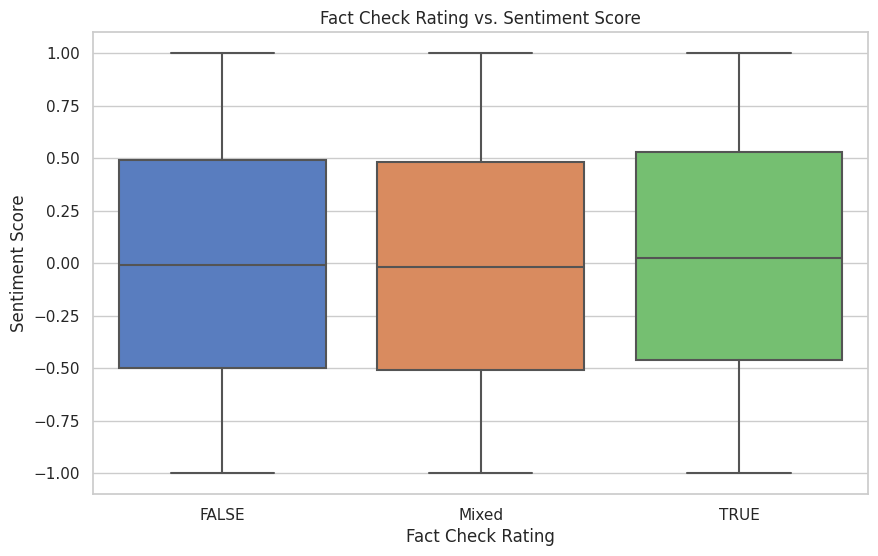

In [20]:
# 9. Fact Check Rating vs. Sentiment Score
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fact_check_rating', y='sentiment_score', palette='muted')
plt.title('Fact Check Rating vs. Sentiment Score')
plt.xlabel('Fact Check Rating')
plt.ylabel('Sentiment Score')
plt.show()

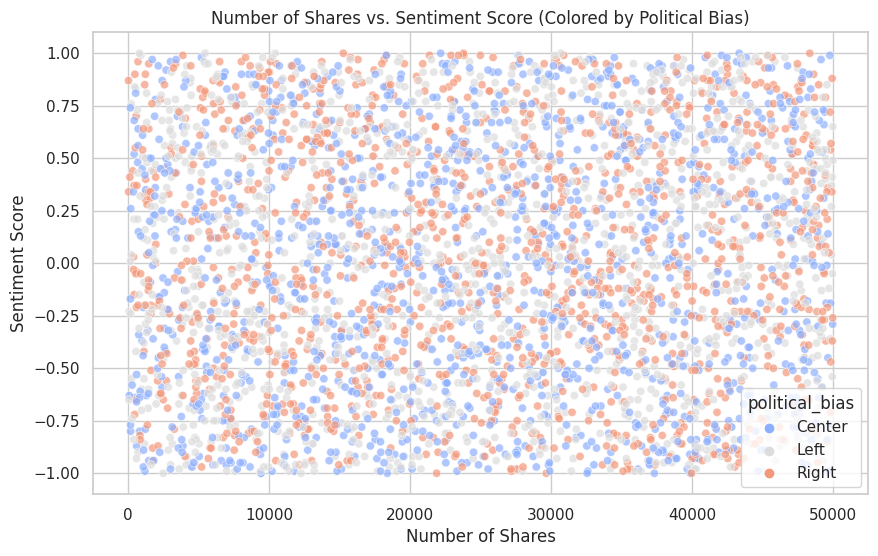

In [21]:
# 10. Number of Shares vs. Sentiment Score (Colored by Political Bias)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='num_shares', y='sentiment_score', hue='political_bias', palette='coolwarm', alpha=0.7)
plt.title('Number of Shares vs. Sentiment Score (Colored by Political Bias)')
plt.xlabel('Number of Shares')
plt.ylabel('Sentiment Score')
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [23]:
df = df.dropna()

In [24]:
# Label Encoding for categorical features like 'category', 'political_bias', and 'label'
label_encoder = LabelEncoder()

In [25]:
# Apply Label Encoding to categorical columns
df['category'] = label_encoder.fit_transform(df['category'])
df['political_bias'] = label_encoder.fit_transform(df['political_bias'])
df['label'] = label_encoder.fit_transform(df['label']) 

In [26]:
# Features and target variable
X = df[['sentiment_score', 'word_count', 'char_count', 'has_images', 'has_videos', 'readability_score', 
        'num_shares', 'num_comments', 'clickbait_score', 'plagiarism_score', 'trust_score', 'source_reputation']]
y = df['label']

In [27]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# List of classifiers to evaluate
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB()
}

In [29]:
# Function to train and evaluate models
def train_and_evaluate_models(classifiers, X_train, X_test, y_train, y_test):
    accuracy_results = {}

    for name, clf in classifiers.items():
        # Train the model
        clf.fit(X_train, y_train)
        
        # Make predictions
        y_pred = clf.predict(X_test)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred) * 100
        
        # Store results
        accuracy_results[name] = accuracy
        print(f"\n{name} Accuracy: {accuracy:.2f}%")
        print(classification_report(y_test, y_pred))

    return accuracy_results

In [30]:
# Run the evaluation
accuracy_results = train_and_evaluate_models(classifiers, X_train, X_test, y_train, y_test)

# Display accuracy for all models
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy (%)'])
print("\nModel Accuracy Comparison:")
print(accuracy_df)


Logistic Regression Accuracy: 53.12%
              precision    recall  f1-score   support

           0       0.54      0.64      0.58       411
           1       0.52      0.42      0.47       389

    accuracy                           0.53       800
   macro avg       0.53      0.53      0.52       800
weighted avg       0.53      0.53      0.53       800


Random Forest Accuracy: 50.25%
              precision    recall  f1-score   support

           0       0.51      0.55      0.53       411
           1       0.49      0.45      0.47       389

    accuracy                           0.50       800
   macro avg       0.50      0.50      0.50       800
weighted avg       0.50      0.50      0.50       800


Support Vector Machine Accuracy: 50.50%
              precision    recall  f1-score   support

           0       0.51      0.70      0.59       411
           1       0.49      0.30      0.37       389

    accuracy                           0.51       800
   macro avg     

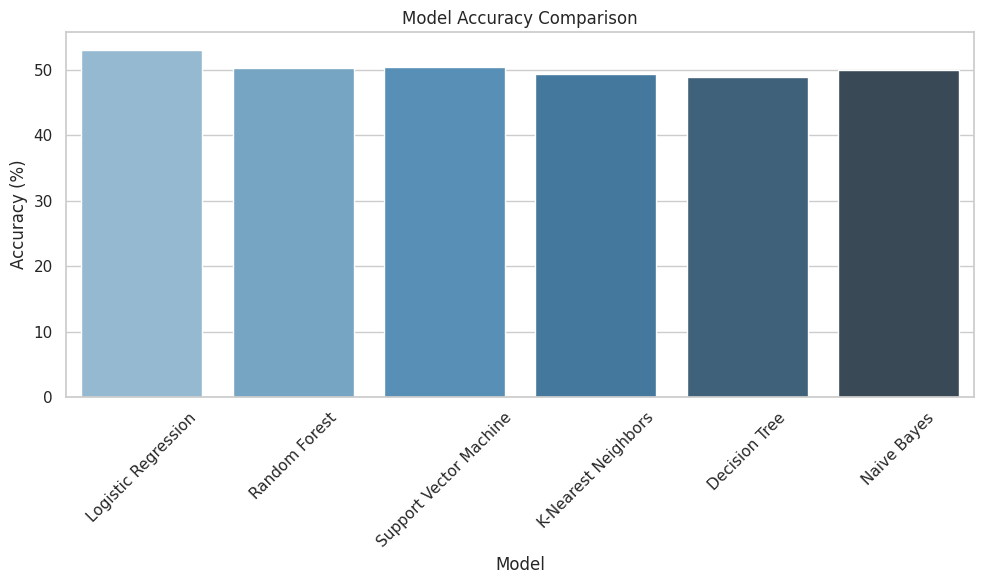

In [31]:
# Plotting the model accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy (%)', data=accuracy_df, palette='Blues_d')

# Adding title and labels
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

## Thank you..pls upvote!!!